# WCC: a transient on a galaxy host (TDAMM)

A supernova or kilonova is rarely found on empty sky: it sits on a host galaxy whose light adds
photon noise and, for nuclear events, can saturate the pixel. This notebook uses `wcc_etc` to ask
**how faint a transient the Wide-field Context Camera (WCC) can detect on a Sersic host, and how
much the answer depends on where in the galaxy it lands.**

Install: [repository setup](../../README.md); browse the [gallery index](../README.md).

**At a glance** · Starter · Package: `wcc_etc`

- **Question:** the bold science question above; aim for one observing decision from the main comparison plot.
- **Prerequisite:** installed [gallery environment](../../README.md), basic Python and magnitudes/SNR.
- **Cost:** scalar/spectral calculations, normally seconds to minutes; cache downloads can add time.
- **First edit:** the Parameters cell below. Restart Kernel and Run All after each change.
- **Output:** plotted comparison plus printed achieved metrics/status.
- **Caveat:** ETC model assumptions and the source template determine the answer; exposure excludes operational overhead.

Section introductions describe the original defaults; the Parameters cell and current outputs are authoritative after edits.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import wcc_etc
from wcc_etc import Simulation, ImageSimulator, get_scene

wcc_etc.set_wcc_style()

## Parameters
Change these inputs first; leave the calculation cells intact.


In [2]:
SOURCE_MAG = 21.0       # SDSS r, AB
HOST_MAG = 16.0         # SDSS r, AB
OFFSET = 0.3            # arcsec from host nucleus
EXPOSURE = 300.0        # total integration, seconds
TEMPLATE_FACTOR = 1.0   # reference integration / science integration


## 1. Build the scene and simulation

A transient at r = 21 (G5V template) 0.3" off the nucleus of an r = 16 elliptical
(Sersic n=4, half-light radius 0.5"), observed in the r band on the in-focus IMX455 sensor.
Both magnitudes are normalized explicitly in SDSS r (AB): `get_scene` otherwise normalizes to
Johnson V (Vega) whatever the observing filter is.

`choose_reads` returns the smallest tested read split whose per-frame image has no saturated pixel, or
an explicit failure. The ETC stamp holds only the source and its host, so a saturated pixel here is
the nucleus (or the transient itself), not an unrelated field star.

In [3]:
scene = get_scene("G5V", mag=SOURCE_MAG, bandpass="sdss_r", magsys="abmag", host="G5V",
                  host_prop={"mag": HOST_MAG, "profile": "sersic", "r_eff": 0.5, "n": 4, "dx": OFFSET,
                             "bandpass": "sdss_r", "magsys": "abmag"},
                  background="zodi")
sim = Simulation.from_sensorfilter("zwo:r", scene)
READS = (1, 2, 3, 5, 10, 30)

def choose_reads(sim, t, reads=READS, **kw):
    """Smallest read count with no saturated pixel in the per-frame image; (None, last result) if none works."""
    for n in reads:
        r = sim.get_image_snr(t, n_reads=n, warn=False, **kw)
        if not np.any(r["saturated"]):
            return n, r
    return None, r

print(f"{'total s':>7} {'reads':>5} {'frame s':>7} {'SNR':>6}  status")
for t in (60, 300, 900):
    n, r = choose_reads(sim, t)
    if n is None:
        print(f"{t:7d} {'-':>5} {'-':>7} {'-':>6}  saturated at every split up to {READS[-1]} reads")
    else:
        print(f"{t:7d} {n:5d} {t / n:7.1f} {r['snr']:6.1f}  ok")

total s reads frame s    SNR  status


[wcc_etc] note: even n_pixels is rounded up by 1 to center the PSF peak (shown once).


     60     1    60.0   64.8  ok
    300     1   300.0  146.9  ok
    900     3   300.0  254.5  ok


## 2. What the detector sees

A single 300 s frame with photon, sky, dark and read noise (`ImageSimulator` renders one read;
the section 1 table shows one 300 s read is unsaturated for this scene).

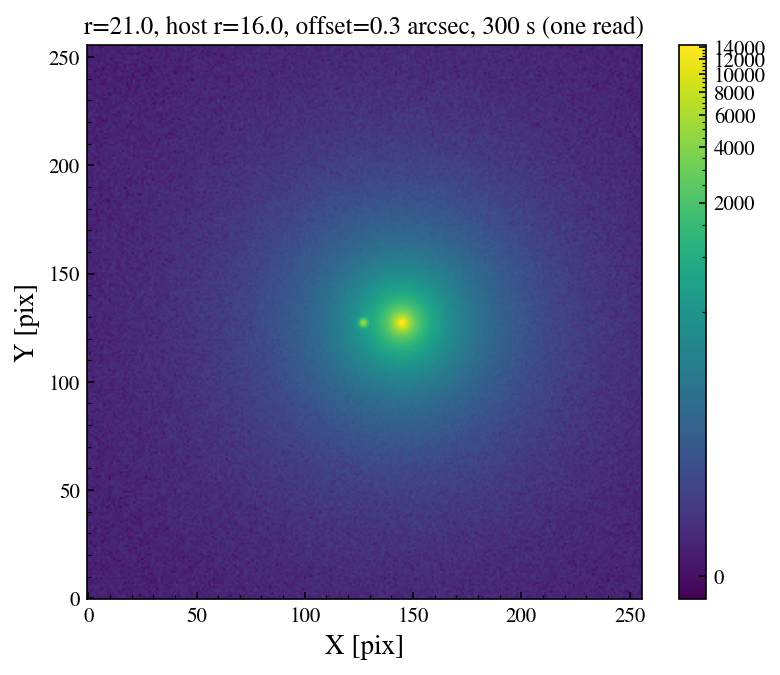

In [4]:
ImageSimulator.from_sensorfilter("zwo:r", scene, npix=256).simulate(EXPOSURE, seed=1).plot_image(
    title=f"r={SOURCE_MAG}, host r={HOST_MAG}, offset={OFFSET} arcsec, {EXPOSURE:g} s (one read)")
plt.show()

## 3. Detection limit versus position on the host

SNR of a 300 s integration as a function of transient magnitude, for a nuclear event, one at
0.5" and one at 1.5" from the nucleus, compared with the same transient on blank sky. Each curve
uses the smallest tested read split that keeps every frame unsaturated (printed below); saturated points
would be omitted. The 5 sigma depth is read off each curve with a guarded interpolation.

These SNRs assume the host flux inside the aperture is known exactly, i.e. the host only adds
photon noise. In practice the transient is measured on a difference image, and the reference
(template) image adds its own noise: $\sigma_\mathrm{diff}^2 = \sigma_\mathrm{sci}^2 +
\sigma_\mathrm{ref}^2$ with the template scaled to the science frame. A template of the same
depth roughly doubles the host-noise variance; a template $k$ times deeper adds only $1/k$ of it.
The dotted curve shows the nuclear case with an equal-depth template.

0.0" from the nucleus     3 x 100 s  5 sigma at r = 23.73


0.5" from the nucleus     2 x 150 s  5 sigma at r = 25.53


1.5" from the nucleus     2 x 150 s  5 sigma at r = 26.46
no host                   2 x 150 s  5 sigma at r = 26.78


Nuclear difference-image 5 sigma depth: r = 23.36


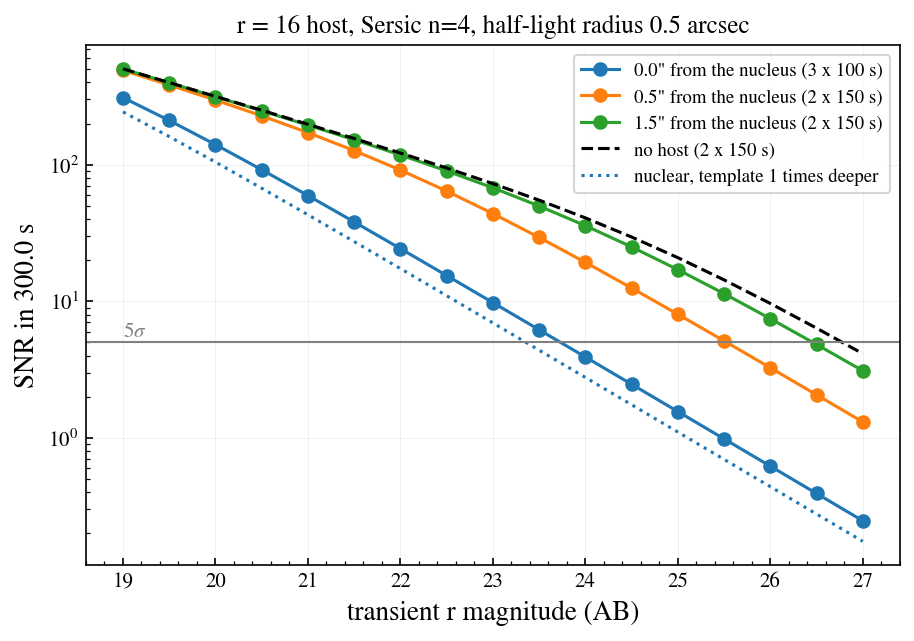

In [5]:
t = EXPOSURE
assert TEMPLATE_FACTOR > 0, "TEMPLATE_FACTOR must be positive"
mags = np.arange(19, 27.5, 0.5)
blank = Simulation.from_sensorfilter("zwo:r", get_scene("G5V", mag=21, bandpass="sdss_r", magsys="abmag"))

def snr_crossing(mags, snr, target=5):
    """Magnitude where a monotonically falling SNR(mag) curve crosses target; NaN if not bracketed."""
    snr = np.asarray(snr, float)
    if not (np.all(np.isfinite(snr)) and np.all(snr > 0) and np.all(np.diff(snr) < 0) and snr.min() < target < snr.max()):
        print("  no valid crossing (non-finite, non-monotonic or unbracketed SNR)")
        return np.nan
    return float(np.interp(np.log(target), np.log(snr[::-1]), mags[::-1]))

depth = {}
fig, ax = plt.subplots(figsize=(7, 4.5))
# the `mags` sweep holds host and background fixed and equals updating source__mag point by point
for label, s, dx, style in [('0.0" from the nucleus', sim, 0.0, "o-"), ('0.5" from the nucleus', sim, 0.5, "o-"),
                            ('1.5" from the nucleus', sim, 1.5, "o-"), ("no host", blank, None, "k--")]:
    if dx is not None:
        s.update(host__dx=dx)
    n, r = choose_reads(s, t, mags=mags)
    snr = np.where(r["saturated"], np.nan, r["snr"])           # never plot a saturated point as valid
    depth[label] = snr_crossing(mags, snr)
    split = f"{n} x {t / n:.0f} s" if n else "saturated points omitted"
    ax.plot(mags, snr, style, label=f"{label} ({split})")
    print(f"{label:22s} {split:>12s}  5 sigma at r = {depth[label]:.2f}")

sim.update(host__dx=0.0)                                        # nuclear case on a difference image
n, r = choose_reads(sim, t, mags=mags)
if n is None:
    print("Nuclear difference image unavailable: no unsaturated science read split.")
else:
    nref, ref = choose_reads(sim, t * TEMPLATE_FACTOR, mags=40.0)
    if nref is None:
        print("Nuclear difference image unavailable: no unsaturated template read split.")
    else:
        snr_diff = r["signal_e"] / np.hypot(r["noise_e"], ref["noise_e"] / TEMPLATE_FACTOR)
        snr_diff = np.where(np.asarray(r["saturated"]) | np.asarray(ref["saturated"]), np.nan, snr_diff)
        depth["nuclear, template"] = snr_crossing(mags, snr_diff)
        ax.plot(mags, snr_diff, ":", color="C0", label=f"nuclear, template {TEMPLATE_FACTOR:g} times deeper")
        print(f"Nuclear difference-image 5 sigma depth: r = {depth['nuclear, template']:.2f}")

ax.axhline(5, color="0.5", lw=1)
ax.text(mags[0], 5.5, "5$\\sigma$", color="0.5")
ax.set(xlabel="transient r magnitude (AB)", ylabel=f"SNR in {t} s", yscale="log",
       title=f"r = {HOST_MAG:g} host, Sersic n=4, half-light radius 0.5 arcsec")
ax.legend(fontsize=9)
plt.show()

## 4. How long a frame before the nucleus saturates?

The IMX455 well depth at this gain setting is only about 16 ke-, so a bright nucleus limits the
single-frame exposure time. Longer total integrations are built by stacking frames. The table gives
the peak pixel of a single frame (`*` = clipped), then the read split a 300 s integration needs and
the SNR of the r = 21 nuclear transient with that split.

In [6]:
print(f"well depth: {sim.sensor.meta['well_depth']:.0f} e-  (peak pixel in e-, * = saturated)\n")
sim.update(source__mag=21.0, host__dx=0.0)
frames = (10, 30, 60, 120, 300)
print(f"{'host r':>6} | " + " ".join(f"{f:>7d} s" for f in frames) + " | 300 s split      SNR")
for host_mag in (14, 16, 18):
    sim.update(host__mag=float(host_mag))
    peaks = [f"{sim.get_peak_pixel(f, units='e-').value:8.0f}{'*' if sim.get_image_snr(f, warn=False)['saturated'] else ' '}"
             for f in frames]
    n, r = choose_reads(sim, 300)
    split = f"{n:2d} x {300 / n:5.1f} s {r['snr']:6.1f}" if n else f"none up to {READS[-1]} reads"
    print(f"{host_mag:6d} | " + " ".join(peaks) + f" | {split}")

well depth: 16275 e-  (peak pixel in e-, * = saturated)

host r |      10 s      30 s      60 s     120 s     300 s | 300 s split      SNR


    14 |     3219      9657     19315*    38630*    96574* | 10 x  30.0 s   24.6


    16 |      633      1899      3797      7594     18986* |  2 x 150.0 s   59.5


    18 |      223       669      1338      2675      6689  |  1 x 300.0 s  123.0


## Reference-run takeaway (original defaults)

**Historical baseline prose:** numerical values below describe the pre-review default run. Use the freshly printed values and plots for current results, especially where this revision corrects an estimator.

On blank sky a 300 s r-band integration reaches 5 sigma at r = 26.8 (AB). An r = 16 elliptical
host costs 0.3 mag of depth for a transient 1.5" out, 1.25 mag at 0.5", and 3.0 mag for a nuclear
event (5 sigma at r = 23.7), because the host's photon noise dominates inside its half-light
radius. Measuring the nuclear transient on a difference image against an equal-depth template
costs another 0.4 mag (5 sigma at r = 23.4); a much deeper template recovers most of that.
With a ~16 ke- well the nucleus of an r = 14 host clips frames longer than 30 s and an r = 16
host with a nuclear transient clips a 300 s frame, so nuclear-transient programs on bright hosts
should stack short frames; the split costs under 1 % in SNR because host photons, not read noise,
dominate.

## Try this

1. Set HOST_MAG to 18 (from 16). Compare nuclear and off-nuclear depths; report the host-noise penalty.
2. Set TEMPLATE_FACTOR to 5. Compare difference-image depth and the extra template time.

**Extension:** Replace the stellar proxy with a physically motivated transient SED; this example is not a SN/kilonova forecast.

Bring back one figure, the requested and achieved metric, an observing decision, and the main limitation.
